In [51]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as T
import numpy as np

In [52]:
class MaskedImageDataset(Dataset):
    def __init__(self, data_dir, categories, transform=None, sample_size=None):
        self.image_paths = []
        self.mask_paths = []
        self.labels = []
        self.class_names = []
        self.transform = transform
        self.label_map = {cat: i for i, cat in enumerate(categories)}
        self.inv_label_map = {i: cat for cat, i in self.label_map.items()}  # Szám → név átalakítás

        for category in categories:
            images_path = os.path.join(data_dir, category, "images")
            masks_path = os.path.join(data_dir, category, "masks")
            
            if not os.path.isdir(images_path) or not os.path.isdir(masks_path):
                continue
            
            files = os.listdir(images_path)
            if sample_size:  # If sample_size is given, limit the number of files
                files = files[:sample_size]  
                
            for file in tqdm(files, desc=f"Loading {category} images"):
                img_path = os.path.join(images_path, file)
                mask_path = os.path.join(masks_path, file)
                
                if os.path.exists(mask_path):
                    self.image_paths.append(img_path)
                    self.mask_paths.append(mask_path)
                    self.labels.append(self.label_map[category])
                    self.class_names.append(category)

    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]
        label = self.labels[idx]
        
        # Load images
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")
    
        # Ensure both image and mask have the same size
        fixed_size = (256, 256)  # Adjust as needed
        image = image.resize(fixed_size, Image.BILINEAR)
        mask = mask.resize(fixed_size, Image.NEAREST)
    
        # Apply transform if provided before converting to tensor
        if self.transform:
            # Apply transform on both image and mask
            image = self.transform(image)
            mask = self.transform(mask)
        
        # Convert mask to binary
        mask = (mask > 0.5).float()
    
        # Expand mask to 3 channels
        mask = mask.repeat(3, 1, 1)
    
        # Ensure both tensors have the same shape
        assert image.shape == mask.shape, f"Shape mismatch: {image.shape} vs {mask.shape}"
    
        # Apply the mask to the image
        masked_image = image * mask
    
        return masked_image, label


In [53]:
# Example usage
categories = ["COVID","Lung_Opacity", "Normal", "Viral Pneumonia"]  # Adatbázis kategóriái
transform = T.Compose([T.Resize((224, 224)), T.ToTensor()])  # Példa transzformációk
dataset = MaskedImageDataset(data_dir='/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset',
                             categories=categories,
                             transform=transform,
                             sample_size=500)

Loading Viral Pneumonia images: 100%|██████████| 500/500 [00:00<00:00, 1622.06it/s]


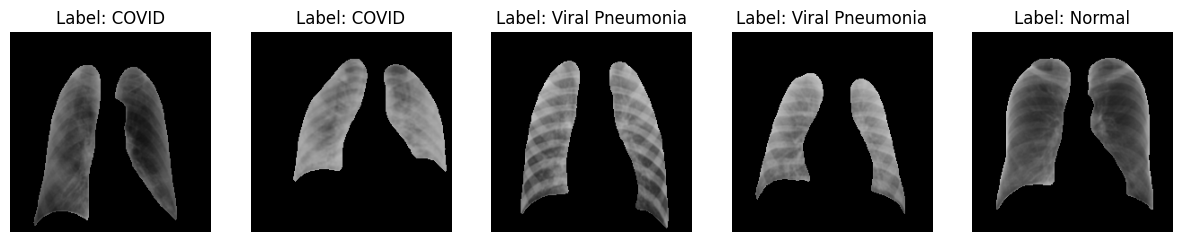

In [54]:
num_workers = os.cpu_count()

dataloader = DataLoader(dataset, batch_size=32, shuffle=True,num_workers=num_workers)

# Display 5 sample images
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i, (imgs, labels) in enumerate(dataloader):
    for j in range(min(5, len(imgs))):
        img = imgs[j].permute(1, 2, 0).numpy()  # Convert to HWC format for plotting
        img = np.clip(img, 0, 1)  # Ensure pixel values are in valid range [0, 1]
        axes[j].imshow(img)
        axes[j].set_title(f"Label: {dataset.inv_label_map[labels[j].item()]}")
        axes[j].axis('off')
    break  # Only show the first batch
plt.show()

In [55]:
import torchvision.models as models
import torch
import numpy as np
from tqdm import tqdm

# CUDA beállítása
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ResNet50 feature extractor beállítása
resnet = models.resnet50(pretrained=True).to(device)
resnet.eval()
feature_extractor = torch.nn.Sequential(*list(resnet.children())[:-1]).to(device)

# Feature-ek kinyerése batchenként
features = []
labels = []

with torch.no_grad():
    for images, batch_labels in tqdm(dataloader, desc="Extracting features"):
        images = images.to(device)  # GPU-ra küldés
        batch_features = feature_extractor(images).squeeze()  # (N, 2048, 1, 1) → (N, 2048)
        features.append(batch_features.cpu().numpy())  # CPU-ra visszavitel

        # Címkék átalakítása számmá, ha szükséges
        if isinstance(batch_labels, list):  # Ha listaként van visszaadva
            labels.extend(batch_labels)  # Szöveges címkék listába
        elif isinstance(batch_labels, torch.Tensor):  # Ha Tensor lenne
            labels.extend(batch_labels.cpu().numpy())

# NumPy tömbbé alakítás
features = np.vstack(features)  # (összes_kép, 2048)
labels = np.array(labels)  # Listából tömb

print("Feature extraction completed!")

Using device: cuda


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Extracting features: 100%|██████████| 63/63 [00:07<00:00,  8.68it/s]

Feature extraction completed!


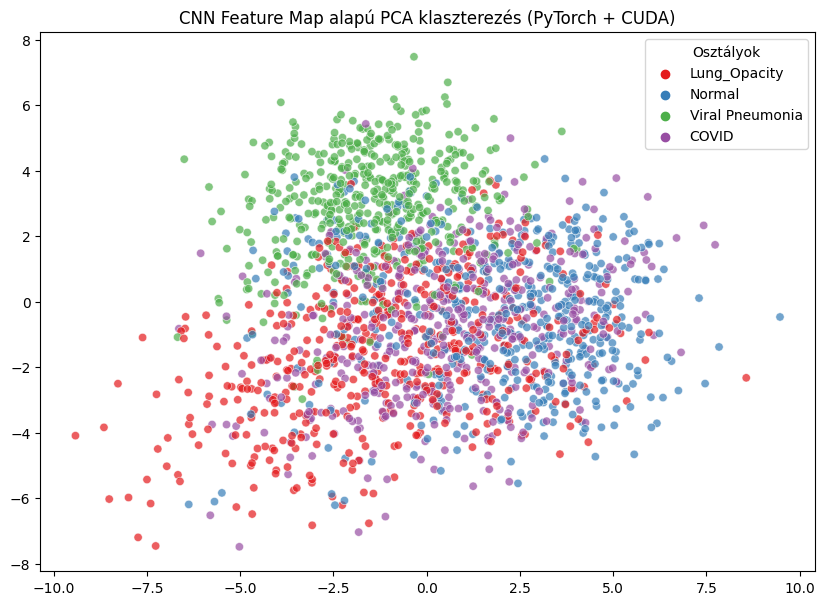

PCA result shape: (2000, 2)
Label names length: 2000


In [56]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# PCA dimenziócsökkentés
pca = PCA(n_components=2)
pca_result = pca.fit_transform(features)


# Convert numeric labels to class names
label_names = [dataset.inv_label_map[label] for label in labels]

# Scatter plot with class names
plt.figure(figsize=(10, 7))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=label_names, palette="Set1", alpha=0.7)
plt.title("CNN Feature Map alapú PCA klaszterezés (PyTorch + CUDA)")
plt.legend(title="Osztályok")
plt.show()
# Hosszok ellenőrzése (debug célból)
print(f"PCA result shape: {pca_result.shape}")
print(f"Label names length: {len(label_names)}")

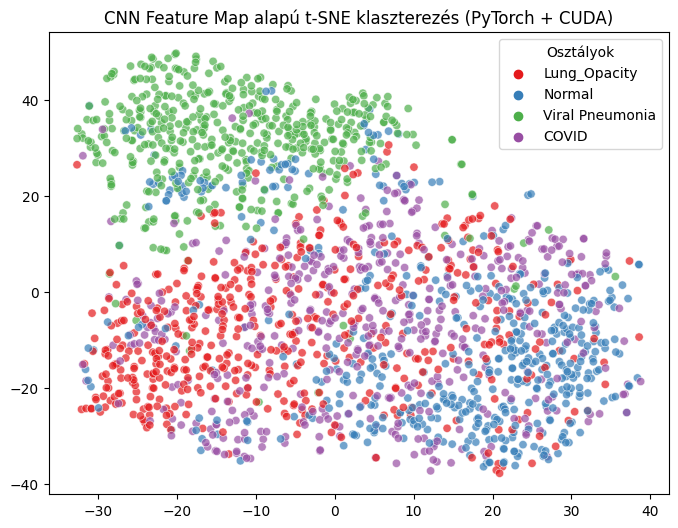

In [57]:
from sklearn.manifold import TSNE


# t-SNE dimenziócsökkentés
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_result = tsne.fit_transform(features)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=tsne_result[:, 0], y=tsne_result[:, 1], hue=label_names, alpha=0.7, palette="Set1")
plt.title("CNN Feature Map alapú t-SNE klaszterezés (PyTorch + CUDA)")
plt.legend(title="Osztályok")
plt.show()

In [59]:
from torchvision import transforms

tranform = transforms.Compose([
    transforms.Resize((256, 256)),  # ResNet bemeneti mérete
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = MaskedImageDataset(data_dir='/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset',
                             categories=categories,
                             transform=transform,
                             sample_size=None)

Loading Viral Pneumonia images: 100%|██████████| 1345/1345 [00:01<00:00, 766.92it/s]


In [60]:
from torch.utils.data import random_split

# Define split ratios
train_ratio = 0.8
val_ratio = 0.10
test_ratio = 0.10

# Calculate split sizes
total_size = len(dataset)
train_size = int(train_ratio * total_size)
val_size = int(val_ratio * total_size)
test_size = total_size - train_size - val_size  # Ensure all samples are used

# Split dataset
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

# Function to count samples per category
def count_per_category(dataset):
    category_counts = {cat: 0 for cat in dataset.dataset.label_map.keys()}
    
    for _, label in dataset:
        category_name = dataset.dataset.inv_label_map[label]
        category_counts[category_name] += 1
    
    return category_counts

# Print category distribution
print("Training Set Distribution:", count_per_category(train_dataset))
print("Validation Set Distribution:", count_per_category(val_dataset))
print("Test Set Distribution:", count_per_category(test_dataset))


Training Set Distribution: {'COVID': 2868, 'Lung_Opacity': 4845, 'Normal': 8138, 'Viral Pneumonia': 1081}
Validation Set Distribution: {'COVID': 373, 'Lung_Opacity': 592, 'Normal': 1031, 'Viral Pneumonia': 120}
Test Set Distribution: {'COVID': 375, 'Lung_Opacity': 575, 'Normal': 1023, 'Viral Pneumonia': 144}


In [61]:
# Define batch size and number of workers (adjust as needed)
batch_size = 32
num_workers = os.cpu_count()  # Or set a fixed number based on your system

# Create DataLoader for each dataset split
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

<ipython-input-62-06706c14163c>:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()  # Automatikus Mixed Precision (AMP)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 196MB/s]
Epoch 1/10 - Training:   0%|          | 0/530 [00:00<?, ?it/s]<ipython-input-62-06706c14163c>:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():  # Mixed Precision
Epoch 1/10 - Training: 100%|██████████| 530/530 [01:10<00:00,  7.54it/s]



Epoch 1/10: Train Loss: 0.4693, Train Acc: 0.8241, Val Loss: 0.4055, Val Acc: 0.8478


Epoch 2/10 - Training: 100%|██████████| 530/530 [01:00<00:00,  8.76it/s]



Epoch 2/10: Train Loss: 0.2579, Train Acc: 0.9063, Val Loss: 0.3698, Val Acc: 0.8691


Epoch 3/10 - Training: 100%|██████████| 530/530 [00:58<00:00,  9.11it/s]


...


Epoch 9/10: Train Loss: 0.0198, Train Acc: 0.9941, Val Loss: 0.3901, Val Acc: 0.9102


Epoch 10/10 - Training: 100%|██████████| 530/530 [00:58<00:00,  9.14it/s]



Epoch 10/10: Train Loss: 0.0191, Train Acc: 0.9944, Val Loss: 0.4297, Val Acc: 0.8951


Testing: 100%|██████████| 67/67 [00:08<00:00,  8.10it/s]



Teszt Loss: 0.4080, Teszt Pontosság: 0.8956


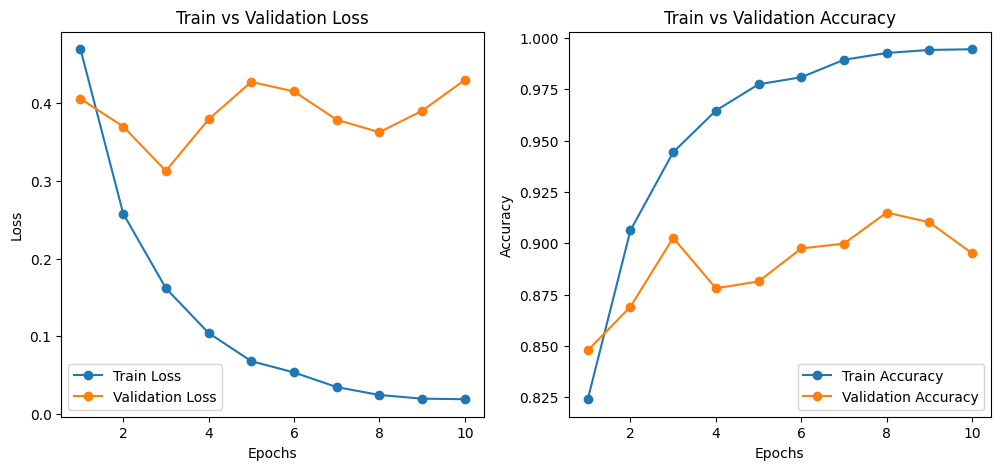

In [62]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import matplotlib.pyplot as plt
from tqdm import tqdm

# CUDA optimalizációk
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.enabled = True

# GPU beállítás
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scaler = torch.cuda.amp.GradScaler()  # Automatikus Mixed Precision (AMP)

# Modell betöltése (ResNet18 finomhangolás)
class COVIDClassifier(nn.Module):
    def __init__(self, num_classes=4):
        super(COVIDClassifier, self).__init__()
        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)

# Modell inicializálása
num_classes = len(categories)
model = COVIDClassifier(num_classes).to(device)

# # Loss függvény és optimalizáló
# criterion = nn.CrossEntropyLoss()
# optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4)

criterion = nn.CrossEntropyLoss()  # Dice loss
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


# Tanítási függvény + teszt kiértékelés
def train_and_evaluate(model, train_loader, val_loader, test_loader, epochs=10, accumulation_steps=2):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct = 0.0, 0
        optimizer.zero_grad()

        for i, (images, labels) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} - Training")):
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            with torch.cuda.amp.autocast():  # Mixed Precision
                outputs = model(images)
                loss = criterion(outputs, labels) / accumulation_steps

            scaler.scale(loss).backward()

            if (i + 1) % accumulation_steps == 0 or i == len(train_loader) - 1:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            train_loss += loss.item() * accumulation_steps * images.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()

        # Validáció
        model.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()

        # Eredmények mentése
        train_loss /= len(train_loader.dataset)
        val_loss /= len(val_loader.dataset)
        train_acc = train_correct / len(train_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"\nEpoch {epoch+1}/{epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Tesztelés
    model.eval()
    test_loss, test_correct = 0.0, 0
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Testing"):
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * images.size(0)
            test_correct += (outputs.argmax(1) == labels).sum().item()

    test_loss /= len(test_loader.dataset)
    test_acc = test_correct / len(test_loader.dataset)

    print(f"\nTeszt Loss: {test_loss:.4f}, Teszt Pontosság: {test_acc:.4f}")

    plot_training_history(history)

# Grafikon rajzolás
def plot_training_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss", marker="o")
    plt.plot(epochs, history["val_loss"], label="Validation Loss", marker="o")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Train vs Validation Loss")

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Accuracy", marker="o")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy", marker="o")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Train vs Validation Accuracy")

    plt.show()

# Tanítás és tesztelés
train_and_evaluate(model, train_loader, val_loader, test_loader, epochs=10, accumulation_steps=4)

# Modell mentése
torch.save(model.state_dict(), "covid_classifier.pth")

<ipython-input-63-b105e43d3ee1>:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("covid_classifier.pth"))


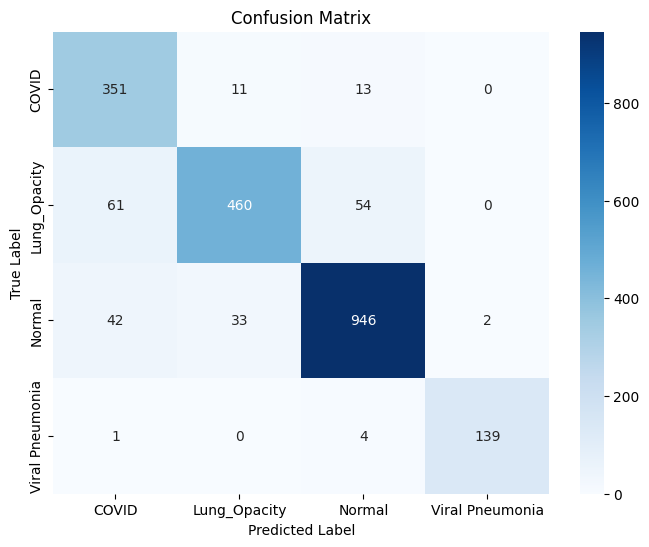


Classification Report:
                 precision    recall  f1-score   support

          COVID     0.7714    0.9360    0.8458       375
   Lung_Opacity     0.9127    0.8000    0.8526       575
         Normal     0.9302    0.9247    0.9275      1023
Viral Pneumonia     0.9858    0.9653    0.9754       144

       accuracy                         0.8956      2117
      macro avg     0.9000    0.9065    0.9003      2117
   weighted avg     0.9011    0.8956    0.8959      2117

Weighted F1-score: 0.8959
Weighted Precision: 0.9011
Weighted Recall: 0.8956
Dice Score for COVID: 0.8458
Dice Score for Lung_Opacity: 0.8526
Dice Score for Normal: 0.9275
Dice Score for Viral Pneumonia: 0.9754

Average Dice Score: 0.9003


In [63]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score, recall_score

# GPU beállítás
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Modell betöltése és kiértékelés előkészítése
model = COVIDClassifier(num_classes=len(categories)).to(device)
model.load_state_dict(torch.load("covid_classifier.pth"))
model.eval()

# Metrikák számítása
def evaluate_model(model, test_loader):
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    # Konfúziós mátrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=categories, yticklabels=categories)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

    # Osztályozási riport (Precision, Recall, F1-score)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=categories, digits=4))

    # F1, Precision, Recall metrikák külön
    f1 = f1_score(y_true, y_pred, average="weighted")
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")

    print(f"Weighted F1-score: {f1:.4f}")
    print(f"Weighted Precision: {precision:.4f}")
    print(f"Weighted Recall: {recall:.4f}")

    # Dice Score kiszámítása minden osztályra
    dice_scores = []
    for class_idx in range(len(categories)):
        true_class = (np.array(y_true) == class_idx).astype(int)
        pred_class = (np.array(y_pred) == class_idx).astype(int)

        intersection = np.sum(true_class * pred_class)
        dice = (2.0 * intersection) / (np.sum(true_class) + np.sum(pred_class) + 1e-6)
        dice_scores.append(dice)

    # Dice Score kiírása
    for i, category in enumerate(categories):
        print(f"Dice Score for {category}: {dice_scores[i]:.4f}")

    # Átlagos Dice Score
    avg_dice = np.mean(dice_scores)
    print(f"\nAverage Dice Score: {avg_dice:.4f}")

# Kiértékelés futtatása
evaluate_model(model, test_loader)